# Datasets

In [1]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

In [2]:
X, y = make_classification(
    n_samples=2500,       
    n_features=20,        
    n_informative=12,      
    n_classes=2,          
    random_state=8       
)

In [3]:
X[:2]

array([[ 0.66393907, -0.08151312, -0.35574504, -2.25523723, -0.82459016,
         0.45469416, -0.24020224, -0.01301753, -2.15150055, -0.20909669,
         1.43943625,  2.27445866,  1.98966981, -0.06946088,  0.07519195,
        -1.39202067,  0.40889453,  1.00180758, -2.70553892,  1.53922232],
       [ 1.93832827,  0.32664886,  1.48643337, -2.02639728, -1.95836646,
         4.80250341,  3.01283631,  0.0772098 ,  1.17200786, -3.12323417,
         0.34412466, -2.89454636,  0.18859416,  6.6140513 , -0.51655982,
         4.92702996, -9.3346991 ,  2.85158828,  0.81600583, -0.58270121]])

In [16]:
y[:2]

array([1, 1])

In [17]:
X.shape

(2500, 20)

In [18]:
y.shape

(2500,)

# Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=8)


In [5]:
X_train.shape

(2000, 20)

In [6]:
X_test.shape

(500, 20)

# Partie 1 : Bagging & Random Forest

## 1.1. Modèle de base

In [5]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

In [53]:
model = DecisionTreeClassifier(random_state=8)

# 5. Train 
start_time = time.time()
model.fit(X_train, y_train)
dt_time = time.time() - start_time

# 6. predictions
predictions = model.predict(X_test)

# 7. Evaluation
accuracy = accuracy_score(y_test, predictions)

print(f"Decision tree Accuracy: {accuracy * 100:.2f}%, Temps d'exécution: {dt_time:.4f}s")

Decision tree Accuracy: 83.20%, Temps d'exécution: 0.0838s


In [9]:


# 7. Evaluation sur l'ensemble d'entrainement

print(f"Model Accuracy: { accuracy_score(y_train, model.predict(X_train))* 100:.2f}%")

Model Accuracy: 100.00%


## 1.2. Implémentation manuelle du Bagging

In [6]:
start_time = time.time()

bootstraps_index = [pd.DataFrame(X_train).sample(len(X_train), replace=True, random_state=68 + i).index for i in range(50)]

X_train_df = pd.DataFrame(X_train)
y_train_series = pd.Series(y_train)

ens_preds = []
for i, index in enumerate(bootstraps_index):
    
    model = DecisionTreeClassifier(random_state=68 + i) 
    
    
    X_boot = X_train_df.iloc[index]
    y_boot = y_train_series.iloc[index]
    
    
    model.fit(X_boot, y_boot)
    y_pred = model.predict(X_test)
    ens_preds.append(y_pred)

df_preds = pd.DataFrame(ens_preds).T


predictions_finales = df_preds.mode(axis=1)[0]

bagg_time = time.time() - start_time

In [29]:
len([pd.DataFrame(ens_preds)[col].value_counts().idxmax() for col in pd.DataFrame(ens_preds).columns])

500

In [30]:
[pd.DataFrame(ens_preds)[col].value_counts().idxmax() for col in pd.DataFrame(ens_preds).columns][:5]

[np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0)]

In [ ]:


predictions_finales[:5]

0    1.0
1    0.0
2    1.0
3    0.0
4    0.0
Name: 0, dtype: float64

In [32]:
bagging_acc = accuracy_score(y_test, predictions_finales)
print(f"Bagging Accuracy: {bagging_acc * 100:.2f}%, Temps d'exécution: {bagg_time:.4f}s")

Bagging Accuracy: 88.60%, Temps d'exécution: 3.2155s


## 1.3. Random Fores

In [33]:
from sklearn.ensemble import RandomForestClassifier

In [38]:
for features in range(1,15):
    model_i = RandomForestClassifier(
    n_estimators=50,
    max_features=features,
    random_state=8
    )

    model_i.fit(X_train, y_train)
    print(f"max_features={features}, Accuracy on test: { accuracy_score(y_test, model_i.predict(X_test))* 100:.2f}% , Accuracy on train: { accuracy_score(y_train, model_i.predict(X_train))* 100:.2f}%,")

max_features=1, Accuracy on test: 86.00% , Accuracy on train: 100.00%,
max_features=2, Accuracy on test: 88.40% , Accuracy on train: 100.00%,
max_features=3, Accuracy on test: 90.00% , Accuracy on train: 100.00%,
max_features=4, Accuracy on test: 89.20% , Accuracy on train: 100.00%,
max_features=5, Accuracy on test: 90.40% , Accuracy on train: 100.00%,
max_features=6, Accuracy on test: 88.80% , Accuracy on train: 100.00%,
max_features=7, Accuracy on test: 89.20% , Accuracy on train: 100.00%,
max_features=8, Accuracy on test: 88.80% , Accuracy on train: 100.00%,
max_features=9, Accuracy on test: 89.60% , Accuracy on train: 100.00%,
max_features=10, Accuracy on test: 90.20% , Accuracy on train: 100.00%,
max_features=11, Accuracy on test: 89.80% , Accuracy on train: 100.00%,
max_features=12, Accuracy on test: 89.00% , Accuracy on train: 100.00%,
max_features=13, Accuracy on test: 89.80% , Accuracy on train: 100.00%,
max_features=14, Accuracy on test: 89.60% , Accuracy on train: 100.00%,


### # **Question**: Pourquoi la limitation des variables à chaque nœud (max_features)améliore-t-elle la diversité des arbres par rapport à un Bagging classique ?

#### # **reponse**: À chaque noeuds la combinaison aleatoire de features inferieure au nombre total de varibles créer des arbres très differentes d'où la diversité ce qui n'est pas le cas du bagging classique qui utilise tous les variables à chaque noeuds

In [35]:
model_rf = RandomForestClassifier(
    n_estimators=50,
    random_state=8,
    max_features = 5
)
start_time = time.time()
model_rf.fit(X_train, y_train)
rf_time = time.time() - start_time

print(f"Model Accuracy on test: { accuracy_score(y_test, model_rf.predict(X_test))* 100:.2f}%")
print(f"Random Forest Time: {rf_time:.4f}s")

Model Accuracy on test: 90.40%
Random Forest Time: 0.6558s


# Partie 2 : Boosting

## 2.1. AdaBoost

In [6]:
from sklearn.ensemble import AdaBoostClassifier

In [7]:

# base model
base = DecisionTreeClassifier(max_depth=1, random_state=68)

# Adaboost
adaboost_model = AdaBoostClassifier(
    estimator=base, 
    n_estimators=50, 
    learning_rate=1.0, 
    random_state=68
)

# Entrainement
adaboost_model.fit(X_train, y_train)

#  Prédiction
y_pred_ada = adaboost_model.predict(X_test)

# Performance
accuracy = accuracy_score(y_test, y_pred_ada)
print(f"Précision d'AdaBoost : {accuracy:.4f}")


Précision d'AdaBoost : 0.7660


In [9]:
np.linspace(0.1, 1.0, 10)

array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ])

In [17]:
for learning_rate in np.linspace(0.1, 2.0, 20):
    adaboost_model = AdaBoostClassifier(
        estimator=base, 
        n_estimators=100, 
        learning_rate=learning_rate, 
        random_state=68
    )
    
    adaboost_model.fit(X_train, y_train)
    y_pred_ada = adaboost_model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred_ada)
    print(f"learning_rate={learning_rate:.1f}, Précision d'AdaBoost : {accuracy:.4f}")

learning_rate=0.1, Précision d'AdaBoost : 0.7860
learning_rate=0.2, Précision d'AdaBoost : 0.7820
learning_rate=0.3, Précision d'AdaBoost : 0.7820
learning_rate=0.4, Précision d'AdaBoost : 0.7840
learning_rate=0.5, Précision d'AdaBoost : 0.7860
learning_rate=0.6, Précision d'AdaBoost : 0.7840
learning_rate=0.7, Précision d'AdaBoost : 0.7880
learning_rate=0.8, Précision d'AdaBoost : 0.7760
learning_rate=0.9, Précision d'AdaBoost : 0.7860
learning_rate=1.0, Précision d'AdaBoost : 0.7760
learning_rate=1.1, Précision d'AdaBoost : 0.7680
learning_rate=1.2, Précision d'AdaBoost : 0.7720
learning_rate=1.3, Précision d'AdaBoost : 0.7620
learning_rate=1.4, Précision d'AdaBoost : 0.7780
learning_rate=1.5, Précision d'AdaBoost : 0.8000
learning_rate=1.6, Précision d'AdaBoost : 0.7860
learning_rate=1.7, Précision d'AdaBoost : 0.7900
learning_rate=1.8, Précision d'AdaBoost : 0.7660
learning_rate=1.9, Précision d'AdaBoost : 0.7460
learning_rate=2.0, Précision d'AdaBoost : 0.6580


`learning_rate`=**1.5**, `accuracy` : **0.8000**

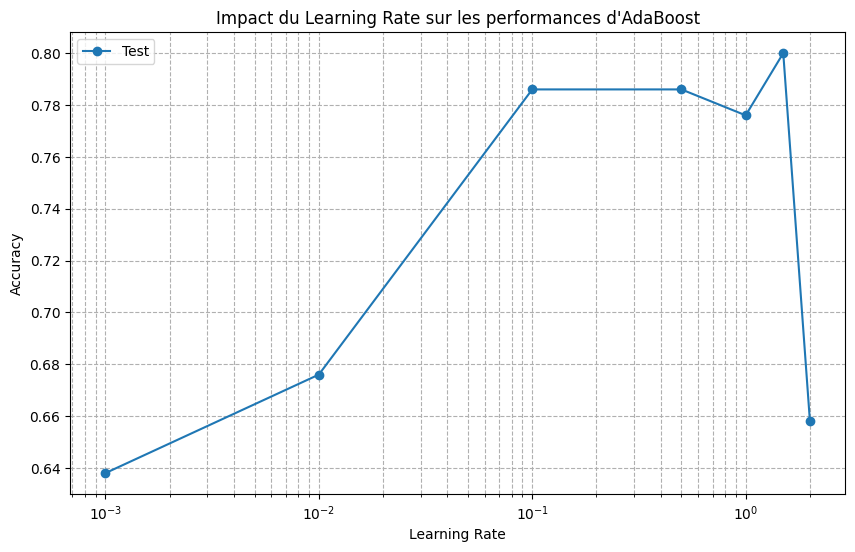

In [27]:

#  Liste des learning rates à tester
learning_rates = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2.0]

test_scores = []

#  Entraînement et évaluation pour chaque valeur
for lr in learning_rates:
    model = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=68),
        n_estimators=100, 
        learning_rate=lr,
        random_state=68
    )
    model.fit(X_train, y_train)
    
    
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

# graphique
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, test_scores, label="Test", marker='o')
plt.xscale('log') # Échelle logarithmique pour mieux voir les petites valeurs
plt.xlabel("Learning Rate")
plt.ylabel("Accuracy")
plt.title("Impact du Learning Rate sur les performances d'AdaBoost")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


In [42]:
# base model
base = DecisionTreeClassifier(max_depth=1, random_state=68)

# Adaboost
adaboost_model = AdaBoostClassifier(
    estimator=base, 
    n_estimators=100, 
    learning_rate=1.5, 
    random_state=68
)

# Entrainement
start_time = time.time()
adaboost_model.fit(X_train, y_train)
ada_time = time.time() - start_time

#  Prédiction
y_pred_ada = adaboost_model.predict(X_test)

# Performance
ada_accuracy = accuracy_score(y_test, y_pred_ada)
print(f"AdaBoost Accuracy: {ada_accuracy * 100:.2f}%, Temps d'exécution: {ada_time:.4f}s")


AdaBoost Accuracy: 80.00%, Temps d'exécution: 1.1845s


## 2.2. Gradient Boosting & XGBoost

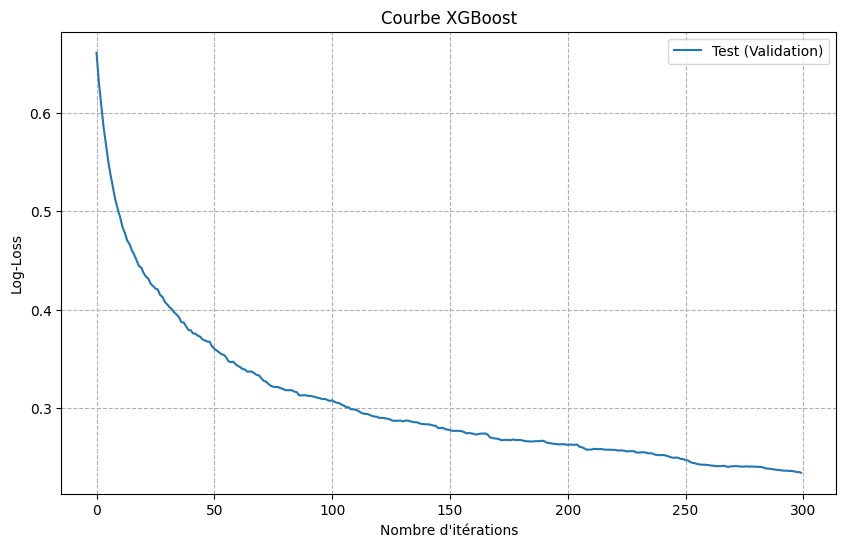

XGBoost - Accuracy: 0.8920, Temps d'exécution: 1.8581s


In [ ]:


from xgboost import XGBClassifier

# Mesure du temps 
start_time = time.time()

# Configuration du modèle
xgb_model = XGBClassifier(
    n_estimators=300,        
    learning_rate=0.1,       
    max_depth=3,             
    random_state=68,
    eval_metric="logloss"    
)

# Entraînement avec suivi des performances en temps réel via eval_set
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False  
)

xgb_time = time.time() - start_time
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

# Récupération des logs pour tracer les courbes
results = xgb_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x = range(0, epochs)

# la courbe Log-Loss
plt.figure(figsize=(10, 6))
plt.plot(x, results['validation_1']['logloss'], label='Test (Validation)')
plt.xlabel("Nombre d'itérations")
plt.ylabel("Log-Loss")
plt.title("Courbe XGBoost")
plt.legend()
plt.grid(True, ls="--")
plt.show()

# performances 
print(f"XGBoost - Accuracy: {xgb_accuracy:.4f}, Temps d'exécution: {xgb_time:.4f}s")


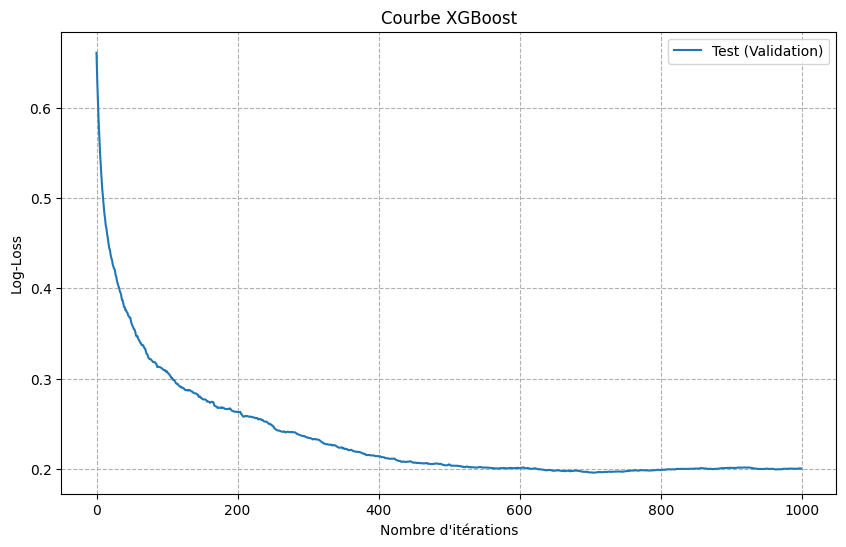

XGBoost - Accuracy: 92.4000, Temps d'exécution: 5.0626s


In [54]:
start_time = time.time()

# Configuration du modèle
xgb_model = XGBClassifier(
    n_estimators=1000,        
    learning_rate=0.1,       
    max_depth=3,             
    random_state=68,
    eval_metric="logloss"    
)

# Entraînement avec suivi des performances en temps réel via eval_set
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False  
)

xgb_time = time.time() - start_time
xgb_pred = xgb_model.predict(X_test)
xgb_accuracy = accuracy_score(y_test, xgb_pred)

# Récupération des logs pour tracer les courbes
results = xgb_model.evals_result()
epochs = len(results['validation_0']['logloss'])
x = range(0, epochs)

# la courbe Log-Loss
plt.figure(figsize=(10, 6))
plt.plot(x, results['validation_1']['logloss'], label='Test (Validation)')

plt.xlabel("Nombre d'itérations")
plt.ylabel("Log-Loss")
plt.title("Courbe XGBoost")
plt.legend()
plt.grid(True, ls="--")
plt.show()

# performances
print(f"XGBoost - Accuracy: {xgb_accuracy*100:.4f}, Temps d'exécution: {xgb_time:.4f}s")

Le **surapprentissage** commence juste après l'itération **700**.